# GammaNet activation on no-shape images: baseline, C-bias and straight-bias

This notebook tests whether the model produces C-like or straight-like activation patterns in images that contain only distractor/noise line elements.

It:
1. selects 50 no-shape images;
2. runs each image under **baseline**, **C-bias**, and **straight-bias**;
3. combines all 128 channels in `h1_exc` into one activation map;
4. saves individual activation heatmaps, mean heatmaps across the 50 images, and bias-minus-baseline difference maps.

The bias implementation and channel lists are the same as in `gammanet_bias_jitter_contour_final(5).ipynb`.

In [1]:
# ============================================================
# No-shape stimulus configuration
# ============================================================
from pathlib import Path

NOSHAPE_IMAGE_DIR = Path("/home/yentl/pytorch_gammanet/Images_no_shape")
NOSHAPE_PATTERN = "Noshape_*.png"
N_NOSHAPE_IMAGES = 25
STIMULUS_CONTRAST = "high"

if not NOSHAPE_IMAGE_DIR.exists():
    raise FileNotFoundError(f"No-shape image directory not found: {NOSHAPE_IMAGE_DIR}")

# noshape_paths = noshape_paths
# if len(noshape_paths) < N_NOSHAPE_IMAGES:
#     raise ValueError(
#         f"Expected at least {N_NOSHAPE_IMAGES} images matching {NOSHAPE_PATTERN}, "
#         f"but found {len(noshape_paths)} in {NOSHAPE_IMAGE_DIR}."
#     )

# print(f"Using {len(noshape_paths)} high-contrast no-shape images.")
# print("First image:", noshape_paths[0].name)
# print("Last image:", noshape_paths[-1].name)


In [2]:
# ============================================================
# 1. Imports, paths and settings
# ============================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_ROOT = Path("/home/yentl/pytorch_gammanet")
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoint_epoch_40.pt"

# CHANGE THIS if the no-shape images are stored elsewhere.
# The notebook searches this folder recursively.
NOSHAPE_IMAGE_DIR = PROJECT_ROOT / "Images_no_shape"

OUTPUT_DIR = PROJECT_ROOT / "outputs_noshape_bias_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSIFICATION_DIR = (
    PROJECT_ROOT / "outputs_bias_contour_final" / "plots" /
    "05_channel_classification" / "channel_classification"
)
C_CHANNELS_CSV = CLASSIFICATION_DIR / "C_channels_h1.csv"
STRAIGHT_CHANNELS_CSV = CLASSIFICATION_DIR / "straight_channels_h1.csv"

INPUT_SIZE = (320, 320)
ANALYSIS_LAYER = "h1_exc"
BIAS_STRENGTH = 0.25
USE_ABS_ACTIVATION = True

N_IMAGES = 25
RANDOM_SAMPLE = True
RANDOM_SEED = 42
SAVE_INDIVIDUAL_HEATMAPS = True
INDIVIDUAL_OVERLAY_ALPHA = 0.55

# Filename labels accepted as no-shape/noise stimuli.
NOSHAPE_LABELS = {"noshape", "no_shape", "no-shape", "noise"}
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
CONDITIONS = ["baseline", "C_bias", "straight_bias"]

transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])

for folder in [
    OUTPUT_DIR / "csv",
    OUTPUT_DIR / "arrays",
    OUTPUT_DIR / "plots" / "individual",
    OUTPUT_DIR / "plots" / "mean_heatmaps",
    OUTPUT_DIR / "plots" / "difference_maps",
    OUTPUT_DIR / "plots" / "comparisons",
]:
    folder.mkdir(parents=True, exist_ok=True)

print("NOSHAPE_IMAGE_DIR:", NOSHAPE_IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CLASSIFICATION_DIR:", CLASSIFICATION_DIR)

/home/yentl/anaconda3/envs/pygestalt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
NOSHAPE_IMAGE_DIR: /home/yentl/pytorch_gammanet/Images_no_shape
OUTPUT_DIR: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final
CLASSIFICATION_DIR: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification


In [3]:
# ============================================================
# 2. Model, activation and plotting helpers
# ============================================================
def load_model():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from gammanet.models.vgg16_gammanet_v2 import VGG16GammaNetV2

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    if "config" in checkpoint and "model" in checkpoint["config"]:
        model_config = checkpoint["config"]["model"]
    elif "model_config" in checkpoint:
        model_config = checkpoint["model_config"]
    else:
        raise KeyError("Could not find model config in checkpoint.")

    model = VGG16GammaNetV2(model_config)
    state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict"))
    if state_dict is None:
        raise KeyError("Could not find model_state_dict or state_dict in checkpoint.")

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE)
    model.eval()
    print("Model timesteps:", model.timesteps)
    return model


def load_image_tensor(path):
    pil_img = Image.open(path).convert("RGB")
    img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    return pil_img, img_tensor


def reset_and_forward(model, img_tensor):
    model.reset_hidden_states()
    with torch.no_grad():
        return model(img_tensor)


def get_state(model, layer_name):
    state = getattr(model, layer_name, None)
    if state is None:
        raise ValueError(f"{layer_name} is None. Run the model first or check the layer name.")
    return state


def all_channel_map(state, use_abs=True, channels=None):
    """Average activation over channels, matching the earlier notebooks."""
    x = state.detach()
    if channels is not None:
        x = x[:, [int(c) for c in channels], :, :]
    if use_abs:
        x = x.abs()
    return x.mean(dim=1)[0].cpu().numpy()


def resize_map_to_image(fmap, pil_img):
    fmap_t = torch.as_tensor(fmap, dtype=torch.float32)[None, None]
    resized = F.interpolate(
        fmap_t,
        size=pil_img.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    return resized[0, 0].numpy()


def normalize_for_plot(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - x.min()
    return x / (x.max() + eps)


def plot_individual_result(pil_img, activation, condition, filename, save_path):
    activation_norm = normalize_for_plot(activation)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(pil_img)
    axes[0].set_title("No-shape stimulus")
    axes[0].axis("off")

    im = axes[1].imshow(activation_norm, cmap="inferno", vmin=0, vmax=1)
    axes[1].set_title(f"{ANALYSIS_LAYER}: all channels\n{condition}")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(pil_img)
    axes[2].imshow(
        activation_norm,
        cmap="inferno",
        alpha=INDIVIDUAL_OVERLAY_ALPHA,
        vmin=0,
        vmax=1,
    )
    axes[2].set_title("Activation overlay")
    axes[2].axis("off")

    fig.suptitle(filename, fontsize=11)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


class TDH1Bias:
    """Same non-invasive td_h1 bias hook as in the jitter notebook."""
    def __init__(self, model, channels, strength=0.25, mode="add_mean_abs"):
        self.model = model
        self.channels = [int(c) for c in channels]
        self.strength = float(strength)
        self.mode = mode
        self.handle = None

    def _hook(self, module, inputs, output):
        if not isinstance(output, tuple):
            return output

        exc = output[0]
        if exc is None or len(self.channels) == 0:
            return output

        exc = exc.clone()
        idx = torch.tensor(self.channels, device=exc.device, dtype=torch.long)

        if self.mode == "add_mean_abs":
            scale = exc.detach().abs().mean(dim=(2, 3), keepdim=True) + 1e-8
            exc[:, idx, :, :] = (
                exc[:, idx, :, :] + self.strength * scale[:, idx, :, :]
            )
        elif self.mode == "multiply":
            exc[:, idx, :, :] = exc[:, idx, :, :] * (1.0 + self.strength)
        else:
            raise ValueError(f"Unknown bias mode: {self.mode}")

        return (exc,) + output[1:]

    def __enter__(self):
        self.handle = self.model.td_fgru_1.register_forward_hook(self._hook)
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        if self.handle is not None:
            self.handle.remove()
        return False


def forward_condition(model, img_tensor, condition, C_CHANNELS, STRAIGHT_CHANNELS):
    if condition == "baseline":
        return reset_and_forward(model, img_tensor)
    if condition == "C_bias":
        with TDH1Bias(model, C_CHANNELS, strength=BIAS_STRENGTH):
            return reset_and_forward(model, img_tensor)
    if condition == "straight_bias":
        with TDH1Bias(model, STRAIGHT_CHANNELS, strength=BIAS_STRENGTH):
            return reset_and_forward(model, img_tensor)
    raise ValueError(f"Unknown condition: {condition}")

In [4]:
# ============================================================
# 3. Load model and contour-selective channel classifications
# ============================================================
model = load_model()

if not C_CHANNELS_CSV.exists() or not STRAIGHT_CHANNELS_CSV.exists():
    raise FileNotFoundError(
        "Channel classification CSVs were not found. Run the contour "
        "classification notebook first, or change CLASSIFICATION_DIR.\n"
        f"Expected C channels at: {C_CHANNELS_CSV}\n"
        f"Expected straight channels at: {STRAIGHT_CHANNELS_CSV}"
    )

C_CHANNELS = pd.read_csv(C_CHANNELS_CSV)["channel"].astype(int).tolist()
STRAIGHT_CHANNELS = pd.read_csv(STRAIGHT_CHANNELS_CSV)["channel"].astype(int).tolist()

print(f"Loaded {len(C_CHANNELS)} C-selective channels")
print(f"Loaded {len(STRAIGHT_CHANNELS)} straight-selective channels")
print("C channels:", C_CHANNELS)
print("Straight channels:", STRAIGHT_CHANNELS)

/tmp/ipykernel_1405/1589221857.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
/home/yentl/anaconda3/envs/

Missing keys: 0
Unexpected keys: 18
Model timesteps: 4
Loaded 61 C-selective channels
Loaded 67 straight-selective channels
C channels: [36, 78, 26, 48, 23, 69, 51, 121, 18, 74, 60, 97, 67, 75, 76, 82, 19, 71, 127, 43, 29, 115, 64, 65, 87, 16, 123, 22, 95, 102, 37, 109, 21, 3, 2, 6, 54, 73, 120, 126, 35, 55, 77, 58, 38, 46, 104, 57, 13, 113, 119, 93, 42, 70, 45, 117, 108, 80, 122, 105, 32]
Straight channels: [98, 56, 92, 27, 101, 107, 0, 86, 79, 124, 96, 8, 103, 44, 49, 30, 59, 15, 116, 31, 100, 114, 88, 17, 11, 106, 5, 90, 4, 81, 33, 111, 34, 39, 83, 24, 125, 66, 85, 52, 10, 12, 25, 63, 9, 110, 40, 28, 7, 68, 91, 47, 14, 112, 20, 72, 89, 61, 50, 94, 1, 62, 41, 118, 53, 99, 84]


In [5]:
# ============================================================
# 4. Find and select 25 no-shape images
# ============================================================
def is_noshape_file(path):
    """Recognise no-shape images from common filename variants."""
    stem = path.stem.lower()
    compact = stem.replace("-", "_")

    if compact.startswith("noshape") or compact.startswith("no_shape"):
        return True

    first_token = compact.split("_")[0]
    return first_token in NOSHAPE_LABELS


all_image_paths = sorted(
    p for p in NOSHAPE_IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)
noshape_paths = [p for p in all_image_paths if is_noshape_file(p)]

print(f"Found {len(all_image_paths)} image files in total")
print(f"Found {len(noshape_paths)} no-shape images")

if len(noshape_paths) < N_IMAGES:
    raise RuntimeError(
        f"Only {len(noshape_paths)} no-shape images were found, but N_IMAGES={N_IMAGES}. "
        "Check NOSHAPE_IMAGE_DIR and the filename labels."
    )

if RANDOM_SAMPLE:
    rng = np.random.default_rng(RANDOM_SEED)
    selected_indices = np.sort(rng.choice(len(noshape_paths), size=N_IMAGES, replace=False))
    selected_paths = [noshape_paths[i] for i in selected_indices]
else:
    selected_paths = noshape_paths[:N_IMAGES]

image_df = pd.DataFrame({
    "image_index": np.arange(len(selected_paths)),
    "filename": [p.name for p in selected_paths],
    "path": [str(p) for p in selected_paths],
})

image_df.to_csv(OUTPUT_DIR / "csv" / "selected_noshape_images.csv", index=False)
display(image_df)
print("Saved selected-image table.")

Found 25 image files in total
Found 25 no-shape images


,image_index,filename,path
0,0,Noshape_000.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
1,1,Noshape_001.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
2,2,Noshape_002.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
3,3,Noshape_003.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
4,4,Noshape_004.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
5,5,Noshape_005.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
6,6,Noshape_006.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
7,7,Noshape_007.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
8,8,Noshape_008.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...
9,9,Noshape_009.png,/home/yentl/pytorch_gammanet/Images_no_shape/N...


Saved selected-image table.


In [6]:
# ============================================================
# 5. Run baseline, C-bias and straight-bias on all 50 images
#    Memory-safe streaming version
# ============================================================
# Only the running sum of the full 128-channel state is kept in RAM.
# The much smaller 2D all-channel activation map is saved immediately
# for each image/condition and is used later for comparison panels.

import gc

state_sums = {condition: None for condition in CONDITIONS}
summary_rows = []

MAP_ARRAY_DIR = OUTPUT_DIR / "arrays" / "per_image_all_channel_maps"
for condition in CONDITIONS:
    (MAP_ARRAY_DIR / condition).mkdir(parents=True, exist_ok=True)

# Inference mode prevents PyTorch from retaining computation graphs.
model.eval()

with torch.no_grad():
    for loop_idx, (_, row) in enumerate(
        tqdm(image_df.iterrows(), total=len(image_df), desc="No-shape images")
    ):
        pil_img, img_tensor = load_image_tensor(row["path"])

        for condition in CONDITIONS:
            forward_condition(
                model=model,
                img_tensor=img_tensor,
                condition=condition,
                C_CHANNELS=C_CHANNELS,
                STRAIGHT_CHANNELS=STRAIGHT_CHANNELS,
            )

            # Move one state to CPU, detached from the model graph.
            state = get_state(model, ANALYSIS_LAYER).detach().cpu()

            if state.shape[1] != 128 and loop_idx == 0:
                print(
                    f"Warning: {ANALYSIS_LAYER} has {state.shape[1]} channels, "
                    "rather than the expected 128. All available channels are used."
                )

            # Running sum: only one full state per condition remains in RAM.
            if state_sums[condition] is None:
                state_sums[condition] = state.clone()
            else:
                state_sums[condition].add_(state)

            # Collapse the current state to a small 2D map immediately.
            fmap = all_channel_map(state, use_abs=USE_ABS_ACTIVATION)
            fmap_resized = resize_map_to_image(fmap, pil_img).astype(np.float32)

            # Save this small map for the later per-image comparison cell.
            map_path = (
                MAP_ARRAY_DIR
                / condition
                / f"{int(row['image_index']):03d}_{Path(row['filename']).stem}_{condition}.npy"
            )
            np.save(map_path, fmap_resized)

            summary_rows.append({
                "image_index": int(row["image_index"]),
                "filename": row["filename"],
                "condition": condition,
                "bias_strength": 0.0 if condition == "baseline" else BIAS_STRENGTH,
                "layer": ANALYSIS_LAYER,
                "n_channels": int(state.shape[1]),
                "mean_abs_activation": float(np.mean(np.abs(fmap_resized))),
                "max_abs_activation": float(np.max(np.abs(fmap_resized))),
                "std_abs_activation": float(np.std(np.abs(fmap_resized))),
                "map_path": str(map_path),
            })

            if SAVE_INDIVIDUAL_HEATMAPS:
                save_dir = OUTPUT_DIR / "plots" / "individual" / condition
                save_dir.mkdir(parents=True, exist_ok=True)
                plot_individual_result(
                    pil_img=pil_img,
                    activation=fmap_resized,
                    condition=condition,
                    filename=row["filename"],
                    save_path=(
                        save_dir
                        / f"{int(row['image_index']):02d}_"
                          f"{Path(row['filename']).stem}_{condition}.png"
                    ),
                )
                plt.close("all")

            # Explicitly release the large temporary state before the next run.
            del state, fmap, fmap_resized

        del img_tensor, pil_img
        gc.collect()

        # This releases unused cached GPU blocks; it does not delete the model.
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

metrics_df = pd.DataFrame(summary_rows)
metrics_df.to_csv(
    OUTPUT_DIR / "csv" / "noshape_activation_metrics_per_image_condition.csv",
    index=False,
)

# This is mathematically the same mean full state as in the original cell.
mean_states = {
    condition: state_sums[condition] / len(image_df)
    for condition in CONDITIONS
}

# Save only the mean full state. Saving all 150 full states is intentionally
# omitted because that was the main RAM bottleneck and is not needed below.
for condition in CONDITIONS:
    torch.save(
        mean_states[condition],
        OUTPUT_DIR / "arrays" / f"mean_noshape_h1_state_{condition}.pt",
    )

condition_summary = (
    metrics_df.groupby("condition", as_index=False)
    .agg(
        n_images=("filename", "nunique"),
        mean_activation=("mean_abs_activation", "mean"),
        sem_activation=("mean_abs_activation", "sem"),
        mean_max_activation=("max_abs_activation", "mean"),
        sem_max_activation=("max_abs_activation", "sem"),
    )
)
condition_summary.to_csv(
    OUTPUT_DIR / "csv" / "noshape_activation_summary_by_condition.csv",
    index=False,
)

display(condition_summary)


No-shape images: 100%|██████████| 25/25 [09:20<00:00, 22.41s/it]


,condition,n_images,mean_activation,sem_activation,mean_max_activation,sem_max_activation
0,C_bias,25,2.572918,0.000902,7.635209,0.280312
1,baseline,25,2.197524,0.000801,7.458317,0.285225
2,straight_bias,25,2.599758,0.001093,8.173256,0.280879


Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/mean_heatmaps/mean_noshape_all_channels_baseline.png


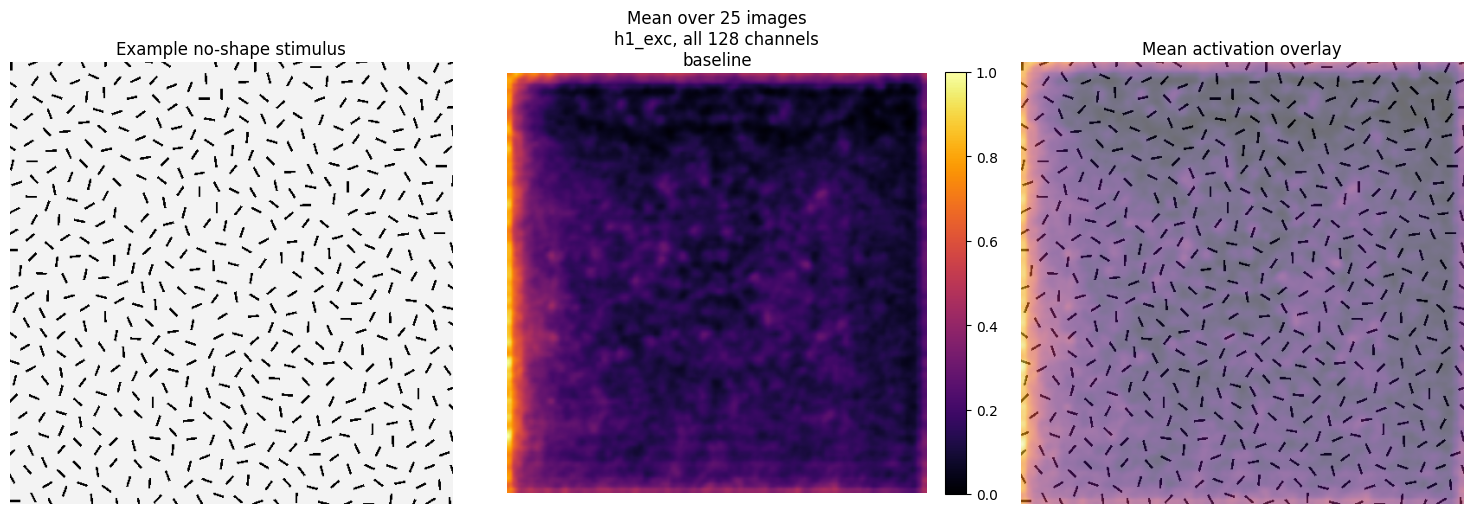

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/mean_heatmaps/mean_noshape_all_channels_C_bias.png


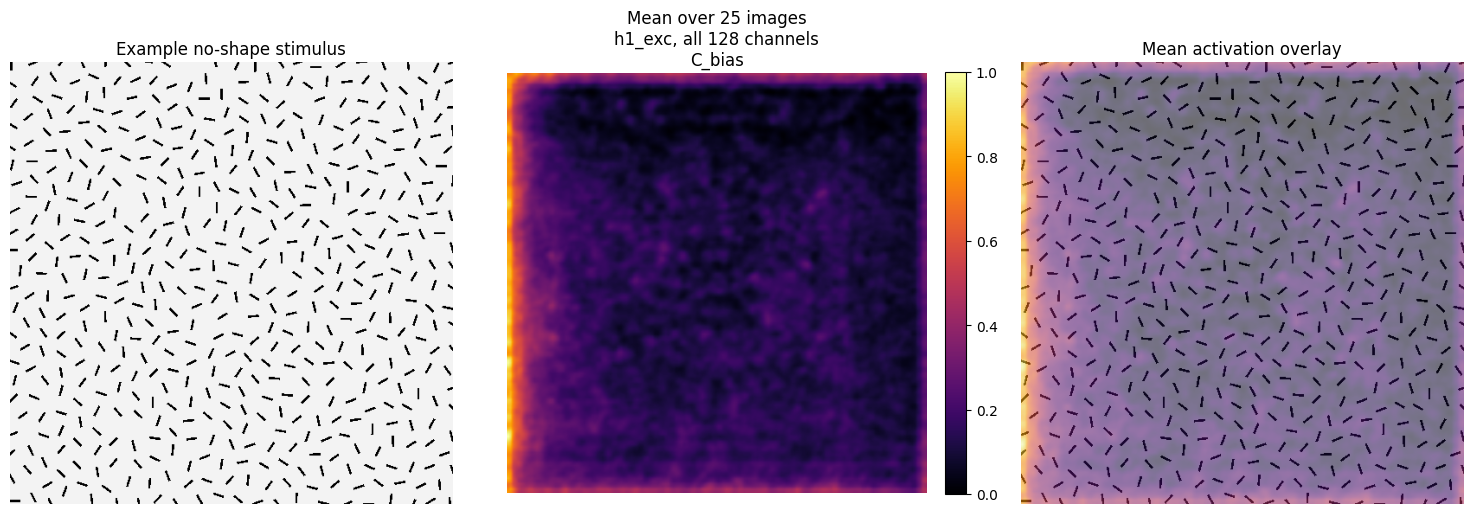

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/mean_heatmaps/mean_noshape_all_channels_straight_bias.png


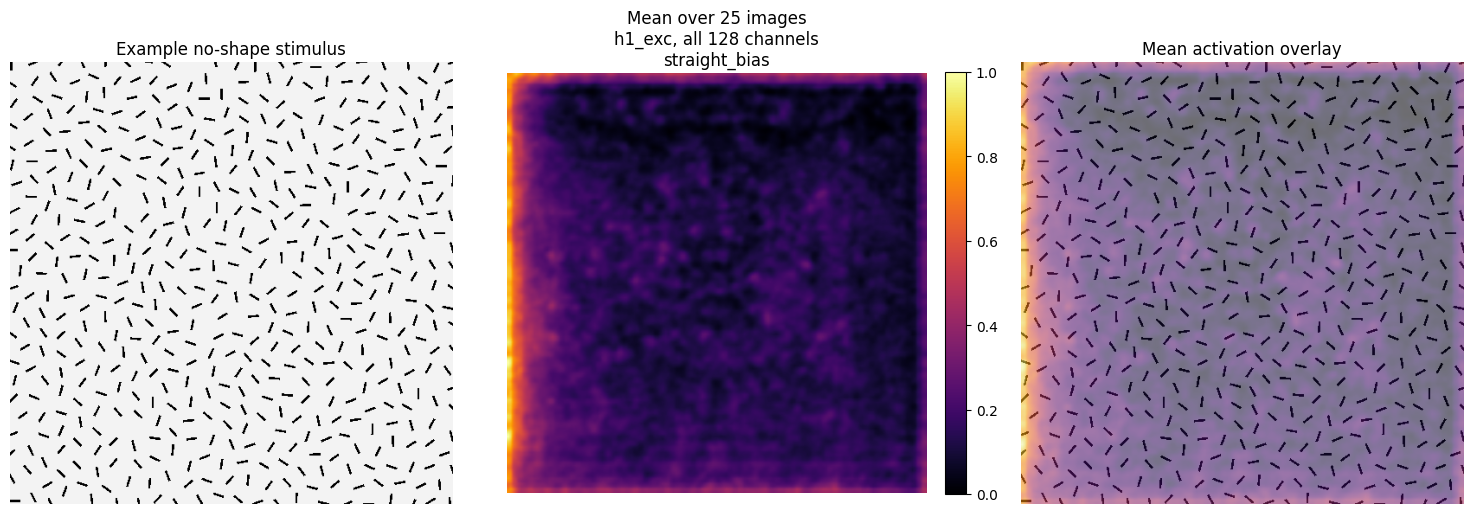

In [7]:
# ============================================================
# 6. Mean all-channel heatmap across the 50 images per condition
# ============================================================
MEAN_HEATMAP_DIR = OUTPUT_DIR / "plots" / "mean_heatmaps"

mean_maps_native = {
    condition: all_channel_map(
        mean_states[condition],
        use_abs=USE_ABS_ACTIVATION,
        channels=None,
    )
    for condition in CONDITIONS
}

# Use one no-shape image only as a spatial reference in the overlay panel.
example_img = Image.open(image_df.iloc[0]["path"]).convert("RGB")

for condition in CONDITIONS:
    mean_map_resized = resize_map_to_image(mean_maps_native[condition], example_img)
    mean_map_norm = normalize_for_plot(mean_map_resized)

    np.save(
        OUTPUT_DIR / "arrays" / f"mean_all_channel_map_{condition}.npy",
        mean_map_resized,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(example_img)
    axes[0].set_title("Example no-shape stimulus")
    axes[0].axis("off")

    im = axes[1].imshow(mean_map_norm, cmap="inferno", vmin=0, vmax=1)
    axes[1].set_title(
        f"Mean over {N_IMAGES} images\n"
        f"{ANALYSIS_LAYER}, all {mean_states[condition].shape[1]} channels\n"
        f"{condition}"
    )
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(example_img)
    axes[2].imshow(mean_map_norm, cmap="inferno", alpha=0.55, vmin=0, vmax=1)
    axes[2].set_title("Mean activation overlay")
    axes[2].axis("off")

    plt.tight_layout()
    save_path = MEAN_HEATMAP_DIR / f"mean_noshape_all_channels_{condition}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()
    plt.close(fig)

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/comparisons/mean_noshape_conditions_shared_scale.png


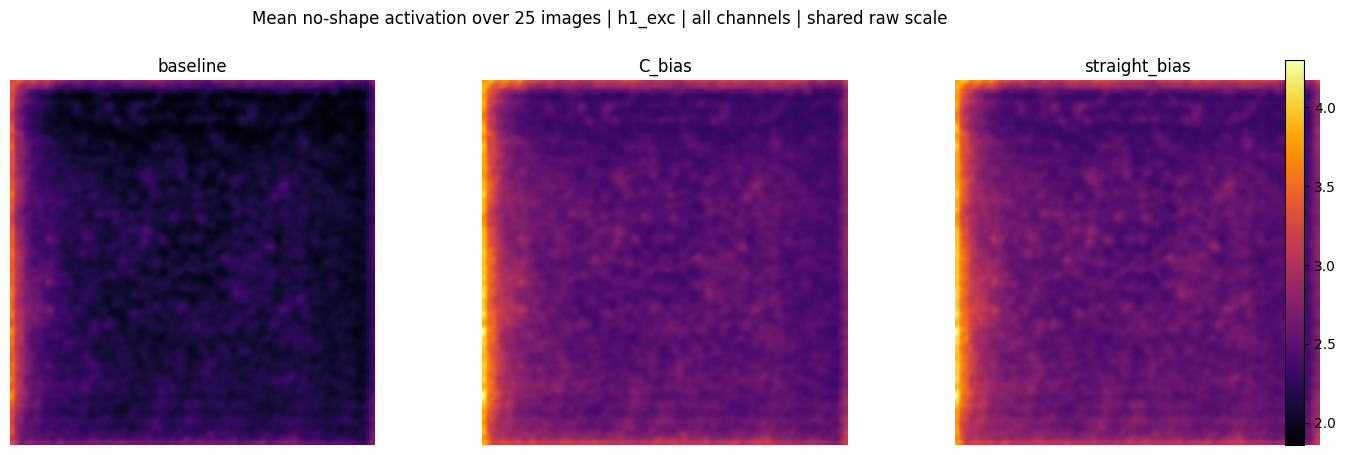

In [8]:
# ============================================================
# 7. Side-by-side comparison using one shared colour scale
# ============================================================
# Shared raw scale prevents each condition from looking equally strong merely
# because it was normalised separately.
mean_maps_resized = {
    condition: resize_map_to_image(mean_maps_native[condition], example_img)
    for condition in CONDITIONS
}

shared_vmin = min(float(x.min()) for x in mean_maps_resized.values())
shared_vmax = max(float(x.max()) for x in mean_maps_resized.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, condition in zip(axes, CONDITIONS):
    im = ax.imshow(
        mean_maps_resized[condition],
        cmap="inferno",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )
    ax.set_title(condition)
    ax.axis("off")

fig.suptitle(
    f"Mean no-shape activation over {N_IMAGES} images | "
    f"{ANALYSIS_LAYER} | all channels | shared raw scale"
)
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
fig.subplots_adjust(top=0.84, wspace=0.05)

save_path = OUTPUT_DIR / "plots" / "comparisons" / "mean_noshape_conditions_shared_scale.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print("Saved:", save_path)
plt.show()
plt.close(fig)

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/difference_maps/C_bias_minus_baseline.png


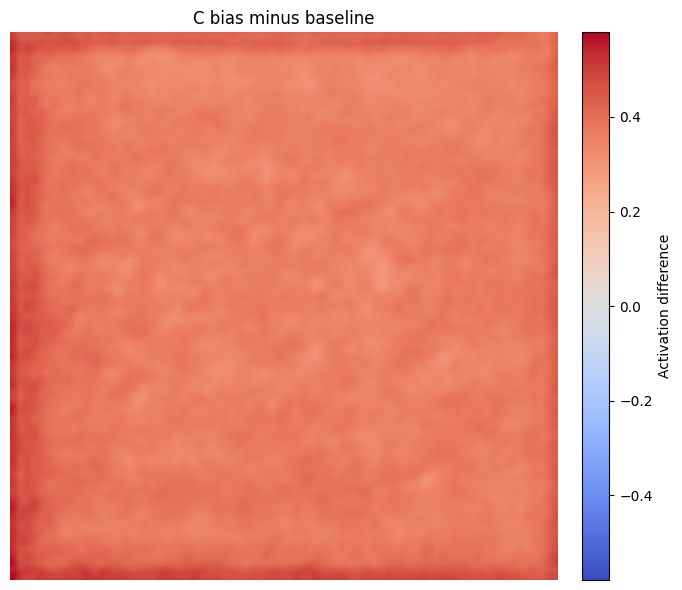

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/difference_maps/straight_bias_minus_baseline.png


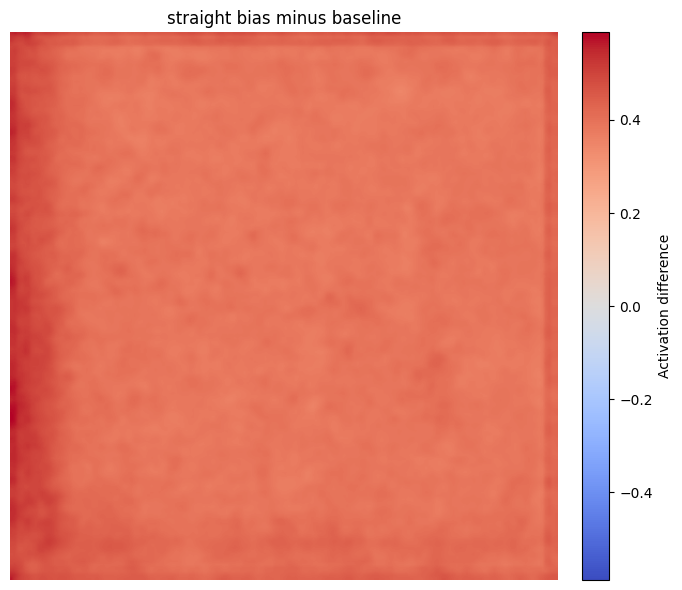

Saved: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/difference_maps/C_bias_minus_straight_bias.png


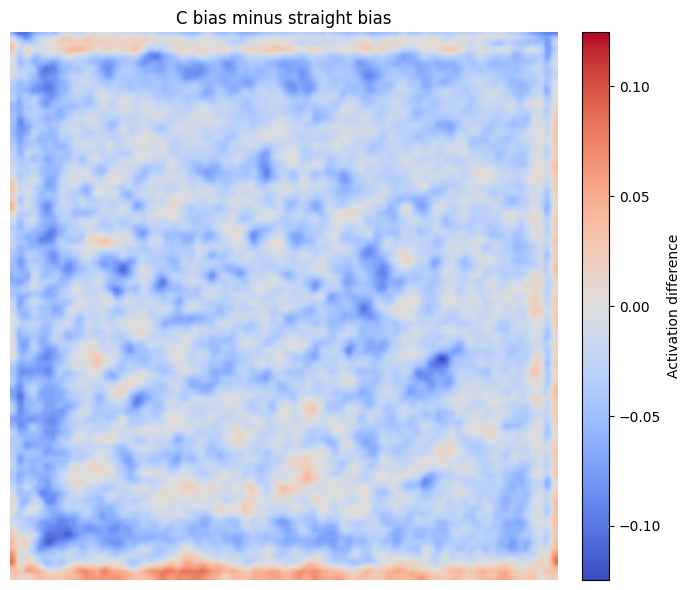

In [9]:
# ============================================================
# 8. Bias-minus-baseline difference maps
# ============================================================
DIFF_DIR = OUTPUT_DIR / "plots" / "difference_maps"

difference_maps = {
    "C_bias_minus_baseline": mean_maps_resized["C_bias"] - mean_maps_resized["baseline"],
    "straight_bias_minus_baseline": mean_maps_resized["straight_bias"] - mean_maps_resized["baseline"],
    "C_bias_minus_straight_bias": mean_maps_resized["C_bias"] - mean_maps_resized["straight_bias"],
}

for name, diff in difference_maps.items():
    np.save(OUTPUT_DIR / "arrays" / f"{name}.npy", diff)

    limit = float(np.max(np.abs(diff)))
    if limit == 0:
        limit = 1e-8

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(diff, cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.set_title(name.replace("_", " "))
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Activation difference")
    plt.tight_layout()

    save_path = DIFF_DIR / f"{name}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()
    plt.close(fig)

In [10]:
# ============================================================
# 9. Per-image baseline / C-bias / straight-bias comparisons
#    Load the small saved 2D maps instead of retaining full states
# ============================================================
PER_IMAGE_COMPARISON_DIR = OUTPUT_DIR / "plots" / "comparisons" / "per_image"
PER_IMAGE_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Comparison panels"):
    pil_img = Image.open(row["path"]).convert("RGB")

    maps = {}
    for condition in CONDITIONS:
        map_path = (
            MAP_ARRAY_DIR
            / condition
            / f"{int(row['image_index']):03d}_{Path(row['filename']).stem}_{condition}.npy"
        )
        maps[condition] = np.load(map_path, mmap_mode="r")

    raw_min = min(float(x.min()) for x in maps.values())
    raw_max = max(float(x.max()) for x in maps.values())

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(pil_img)
    axes[0].set_title("No-shape stimulus")
    axes[0].axis("off")

    for ax, condition in zip(axes[1:], CONDITIONS):
        im = ax.imshow(maps[condition], cmap="inferno", vmin=raw_min, vmax=raw_max)
        ax.set_title(condition)
        ax.axis("off")

    fig.suptitle(row["filename"], fontsize=11)
    fig.colorbar(im, ax=axes[1:].ravel().tolist(), fraction=0.02, pad=0.02)
    fig.subplots_adjust(top=0.86, wspace=0.05)

    save_path = (
        PER_IMAGE_COMPARISON_DIR
        / f"{int(row['image_index']):02d}_{Path(row['filename']).stem}_comparison.png"
    )
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    del maps, pil_img
    gc.collect()

print("Saved per-image comparison panels to:", PER_IMAGE_COMPARISON_DIR)


Comparison panels: 100%|██████████| 25/25 [00:21<00:00,  1.16it/s]

Saved per-image comparison panels to: /home/yentl/pytorch_gammanet/outputs_noshape_bias_final/plots/comparisons/per_image


## Output interpretation

- The **individual comparison panels** are the primary output for asking whether a particular noise image evokes a C-like or straight-like spatial pattern.
- The **mean heatmaps** show spatial tendencies that recur across many no-shape images.
- The **difference maps** show where each bias systematically increases or decreases activation relative to baseline.
- The heatmaps average all available `h1_exc` channels (normally 128), exactly as in the earlier contour and jitter notebooks.

A visually contour-like heatmap does not by itself prove that the model has detected a contour. It shows where the combined recurrent representation is strongest. A later extension could quantify similarity between these no-shape activation maps and C/straight contour templates or reference activation maps.